# City-level sensitivity plots by density

This notebook mirrors the logic of `05d-model6-sensitivity-table-r2.ipynb` for the city analysis, comparing `raw` versus a selected imputed input for `capital` and `fuas` using Model 6 outputs.

In [17]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
wd = '/your/path/to/working/directory/'

countries = {
    'Argentina': 'ARG',
    'Chile': 'CHL',
    'Colombia': 'COL',
}

places = ['capital', 'fuas']
imputed_version = 'censored10'  # options: 'standard', 'subunit0', 'censored10'
raw_version = 'raw'

plot_dir = os.path.join(wd, 'plots', 'city-model6-sensitivity-r2')
os.makedirs(plot_dir, exist_ok=True)

In [19]:
def version_suffix_candidates(version):
    if version == 'standard':
        return ['_new', '', '_standard']
    if version == 'raw':
        return ['', '_raw', '_raw_adjusted_no_imputation_r2']
    if version in {'subunit0', 'censored10'}:
        return [f'_{version}']
    raise ValueError("version must be one of: 'standard', 'subunit0', 'censored10', 'raw'")


def resolve_existing_file(base_dir, filename_candidates):
    for name in filename_candidates:
        path = Path(base_dir) / name
        if path.exists():
            return str(path)
    tried = '\n'.join(str(Path(base_dir) / name) for name in filename_candidates)
    raise FileNotFoundError(f'Could not find any of:\n{tried}')


def read_model_outputs(country_short, place, version, model_id=6):
    base = os.path.join(wd, 'data', 'outputs', country_short, 'mov-analysis', 'by-density')
    suffixes = version_suffix_candidates(version)

    tidy_candidates = [f'data_trend_netflows_{place}_param_tidy_results_cat{s}.csv' for s in suffixes]
    re_candidates = [f'data_trend_param_{place}_m{model_id}cat_re{s}.csv' for s in suffixes]

    tidy_file = resolve_existing_file(base, tidy_candidates)
    re_file = resolve_existing_file(base, re_candidates)
    return pd.read_csv(tidy_file), pd.read_csv(re_file)


def first_or_nan(series):
    series = series.reset_index(drop=True)
    return series.loc[0] if len(series) > 0 else np.nan


def extract_model_by_category(df_tidy, df_re, country_short, place, data_version, model_id=6):
    df_model = df_tidy[df_tidy['model'] == model_id].copy().reset_index(drop=True)

    fe_intercept = first_or_nan(df_model[df_model['term'].astype(str).str.contains('Intercept', na=False)]['estimate'])
    fe_time = first_or_nan(df_model[df_model['term'] == 'time']['estimate'])

    re_intercept = df_re[df_re['facet'].astype(str).str.contains('Intercept', na=False)].copy().reset_index(drop=True)
    re_time = df_re[df_re['facet'] == 'time'].copy().reset_index(drop=True)

    rows = []
    n_rows = min(len(re_intercept), len(re_time))
    for i in range(n_rows):
        category = re_intercept.loc[i, 'term']
        rows.append({
            'country': country_short,
            'place': place,
            'category': category,
            'data_version': data_version,
            'model': model_id,
            'intercept_estimate': fe_intercept + re_intercept.loc[i, 'estimate'],
            'intercept_conf_low': fe_intercept + re_intercept.loc[i, 'conf.low'],
            'intercept_conf_high': fe_intercept + re_intercept.loc[i, 'conf.high'],
            'time_estimate': fe_time + re_time.loc[i, 'estimate'],
            'time_conf_low': fe_time + re_time.loc[i, 'conf.low'],
            'time_conf_high': fe_time + re_time.loc[i, 'conf.high'],
        })

    return pd.DataFrame(rows)


def needs_model5_fallback(df_extracted):
    check_cols = [
        'intercept_estimate', 'intercept_conf_low', 'intercept_conf_high',
        'time_estimate', 'time_conf_low', 'time_conf_high',
    ]
    return df_extracted.empty or df_extracted[check_cols].isna().any().any()


def extract_with_fallback(country_short, place, data_version):
    df_tidy, df_re = read_model_outputs(country_short, place, data_version, model_id=6)
    df_extracted = extract_model_by_category(df_tidy, df_re, country_short, place, data_version, model_id=6)

    if needs_model5_fallback(df_extracted):
        df_tidy, df_re = read_model_outputs(country_short, place, data_version, model_id=5)
        df_extracted = extract_model_by_category(df_tidy, df_re, country_short, place, data_version, model_id=5)

    return df_extracted


def order_categories(df_plot):
    df_plot = df_plot.copy()
    df_plot['category_num'] = pd.to_numeric(df_plot['category'], errors='coerce')
    if df_plot['category_num'].notna().all():
        df_plot = df_plot.sort_values('category_num').reset_index(drop=True)
        # Keep the original density-class positions so missing classes leave empty slots.
        df_plot['x'] = df_plot['category_num'] + 1
    else:
        df_plot = df_plot.sort_values('category').reset_index(drop=True)
        df_plot['x'] = np.arange(1, len(df_plot) + 1)
    return df_plot

In [20]:
records = []
for country_short in countries.values():
    for place in places:
        for version in [imputed_version, raw_version]:
            records.append(extract_with_fallback(country_short, place, version))

df_long = pd.concat(records, ignore_index=True)
df_long.head()

,country,place,category,data_version,model,intercept_estimate,intercept_conf_low,intercept_conf_high,time_estimate,time_conf_low,time_conf_high
0,ARG,capital,0,censored10,6,-36.785192,-38.481830,-35.088555,0.440412,0.136984,0.743841
1,ARG,capital,1,censored10,6,-38.984548,-40.683889,-37.285207,0.352326,0.048805,0.655847
2,ARG,capital,2,censored10,6,-35.250562,-36.947200,-33.553924,0.470636,0.167210,0.774062
3,ARG,capital,3,censored10,6,-36.007509,-37.711495,-34.303523,0.378896,0.075185,0.682608
4,ARG,capital,0,raw,6,-29.616237,-32.111247,-27.121227,0.452607,0.161341,0.743874


In [21]:
def get_axis_limits(df_long, estimate_col, low_col, high_col, padding_ratio=0.08):
    values = pd.concat([
        df_long[estimate_col],
        df_long[low_col],
        df_long[high_col],
    ], axis=0).replace([np.inf, -np.inf], np.nan).dropna()
    if len(values) == 0:
        return None
    vmin = values.min()
    vmax = values.max()
    span = vmax - vmin
    pad = span * padding_ratio if span > 0 else max(abs(vmin) * padding_ratio, 0.1)
    return (vmin - pad, vmax + pad)


intercept_ylim = get_axis_limits(df_long, 'intercept_estimate', 'intercept_conf_low', 'intercept_conf_high')
time_ylim = get_axis_limits(df_long, 'time_estimate', 'time_conf_low', 'time_conf_high')
intercept_ylim, time_ylim

((-89.15443372680099, 3.7883431447715017),
 (-0.6824335564987809, 1.3137324724474189))

In [22]:
def plot_city_comparison(df_long, country_short, place, plot_dir, intercept_ylim=None, time_ylim=None):
    subset = df_long[(df_long['country'] == country_short) & (df_long['place'] == place)].copy()
    subset = order_categories(subset)

    imputed_label_map = {
        'standard': 'Standard imputation',
        'subunit0': 'Subunit0 imputation',
        'censored10': 'Censored imputation (<10)',
    }
    label_map = {
        imputed_version: imputed_label_map.get(imputed_version, imputed_version),
        raw_version: 'Raw adjusted, no imputation',
    }
    color_map = {
        'standard': 'lightsalmon',
        'subunit0': 'goldenrod',
        'censored10': 'darkorange',
        raw_version: 'crimson',
    }
    offset_map = {
        imputed_version: -0.08,
        raw_version: 0.08,
    }

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 8.5), sharex=True)

    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelsize=13, pad=8)
        ax.axhline(0, color='k', linestyle=':', linewidth=1.5, zorder=0)

    for version in [raw_version, imputed_version]:
        df_version = subset[subset['data_version'] == version].copy().reset_index(drop=True)
        df_version = order_categories(df_version)
        if df_version.empty:
            continue

        x = df_version['x'] + offset_map[version]

        intercept_left = df_version['intercept_estimate'] - df_version['intercept_conf_low']
        intercept_right = df_version['intercept_conf_high'] - df_version['intercept_estimate']
        ax1.errorbar(
            x,
            df_version['intercept_estimate'],
            yerr=[intercept_left, intercept_right],
            fmt='o',
            color=color_map[version],
            ecolor=color_map[version],
            elinewidth=2,
            capsize=4,
            markersize=6,
            label=label_map[version],
            zorder=3,
        )

        time_left = df_version['time_estimate'] - df_version['time_conf_low']
        time_right = df_version['time_conf_high'] - df_version['time_estimate']
        ax2.errorbar(
            x,
            df_version['time_estimate'],
            yerr=[time_left, time_right],
            fmt='o',
            color=color_map[version],
            ecolor=color_map[version],
            elinewidth=2,
            capsize=4,
            markersize=6,
            label=label_map[version],
            zorder=3,
        )

    xticks = np.arange(1, 6)
    xticklabels = ['', '', '', '', '']
    xticklabels[0] = 'Less\ndense'
    xticklabels[-1] = 'More\ndense'

    ax1.set_ylabel('Intercept', fontsize=15)
    ax2.set_ylabel('Time term', fontsize=15)
    ax2.set_xticks(xticks)
    ax2.set_xticklabels(xticklabels, fontsize=12)

    if intercept_ylim is not None:
        ax1.set_ylim(intercept_ylim)
    if time_ylim is not None:
        ax2.set_ylim(time_ylim)

    ax1.set_ylim([-85, 42])
    ax2.set_ylim([-0.70, 1.25])
        
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=12)
    fig.suptitle(f"{country_short} - {'Capital' if place == 'capital' else 'FUAs'}", fontsize=17, y=1.06)
    fig.tight_layout()

    plot_path = os.path.join(plot_dir, f'{country_short}_{place}_density_model6_{imputed_version}_vs_raw_r2.pdf')
    fig.savefig(plot_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return plot_path

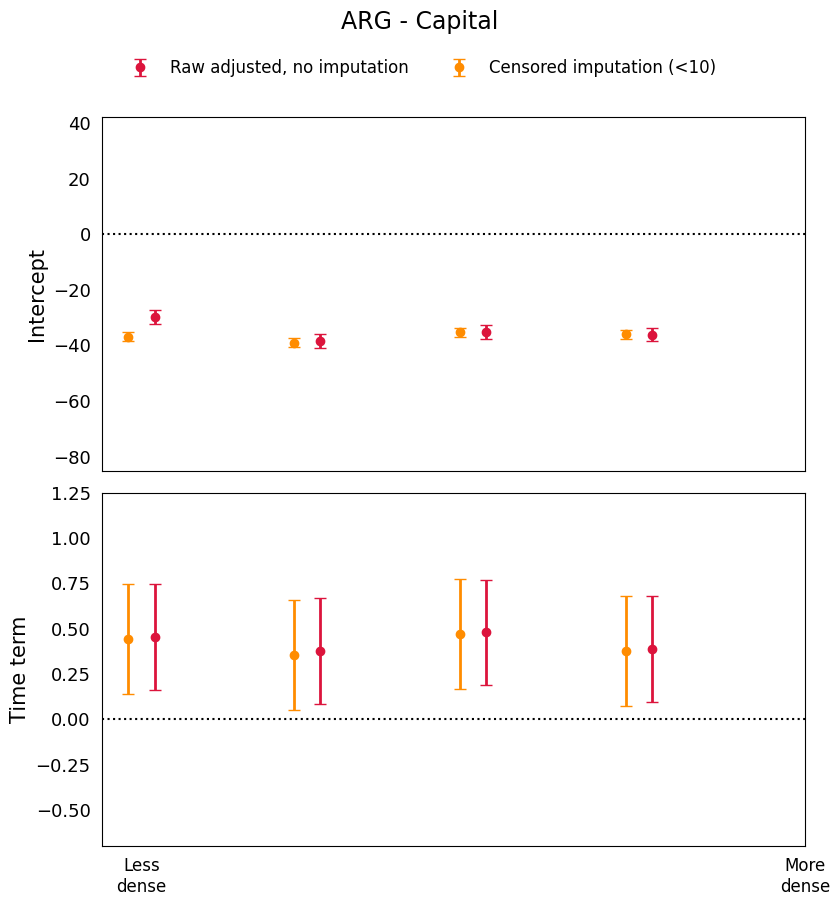

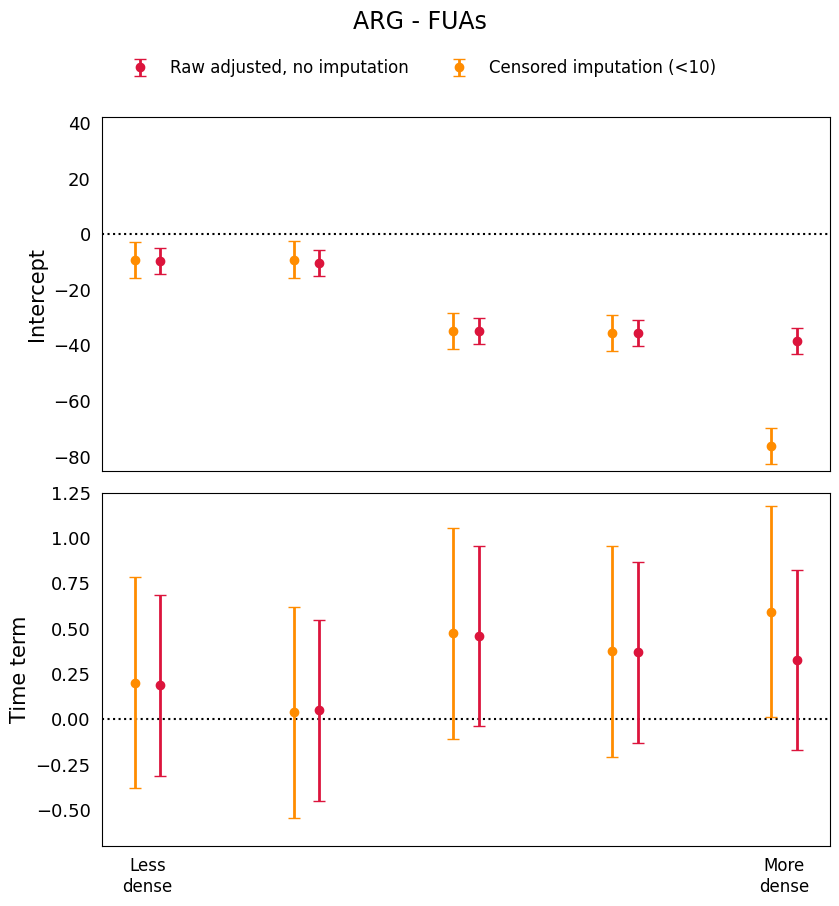

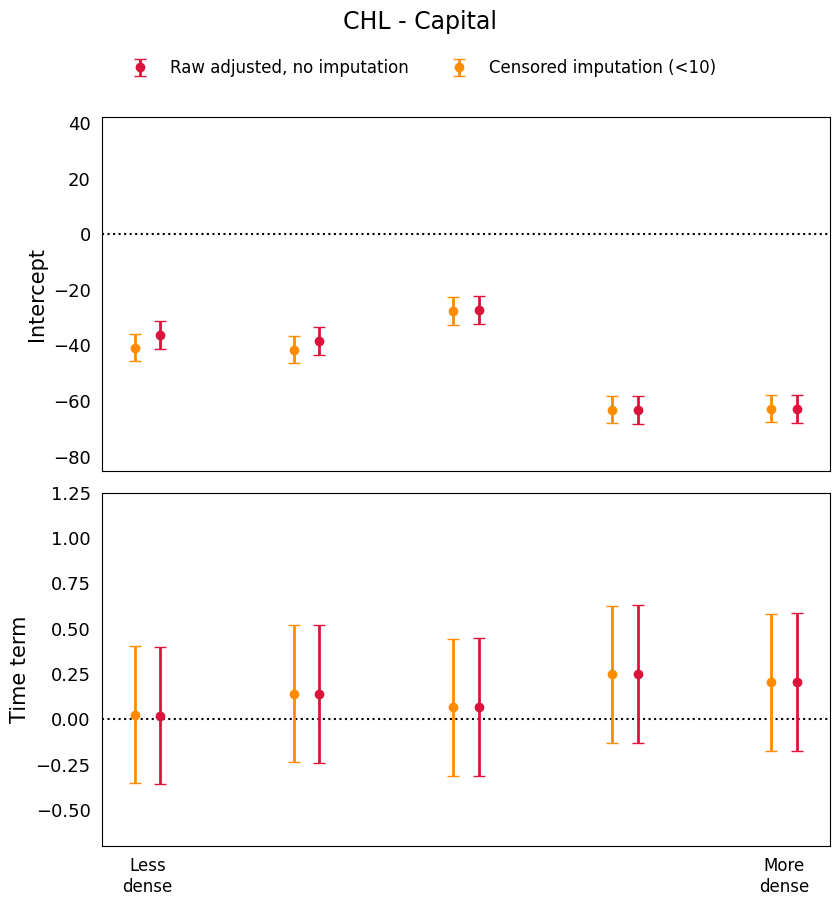

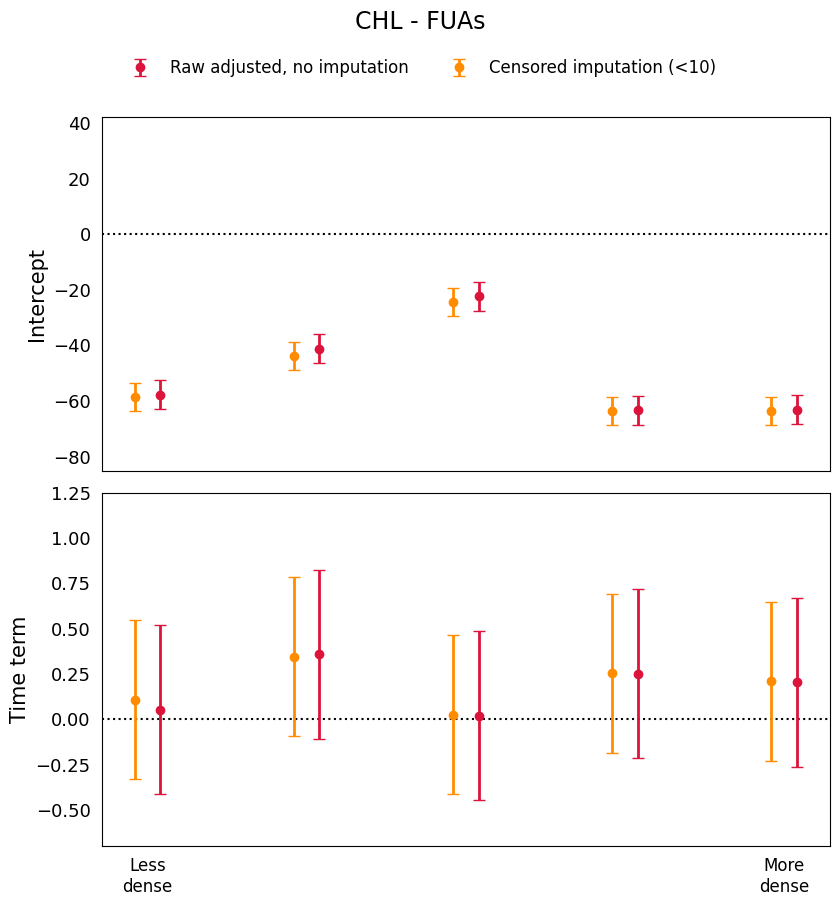

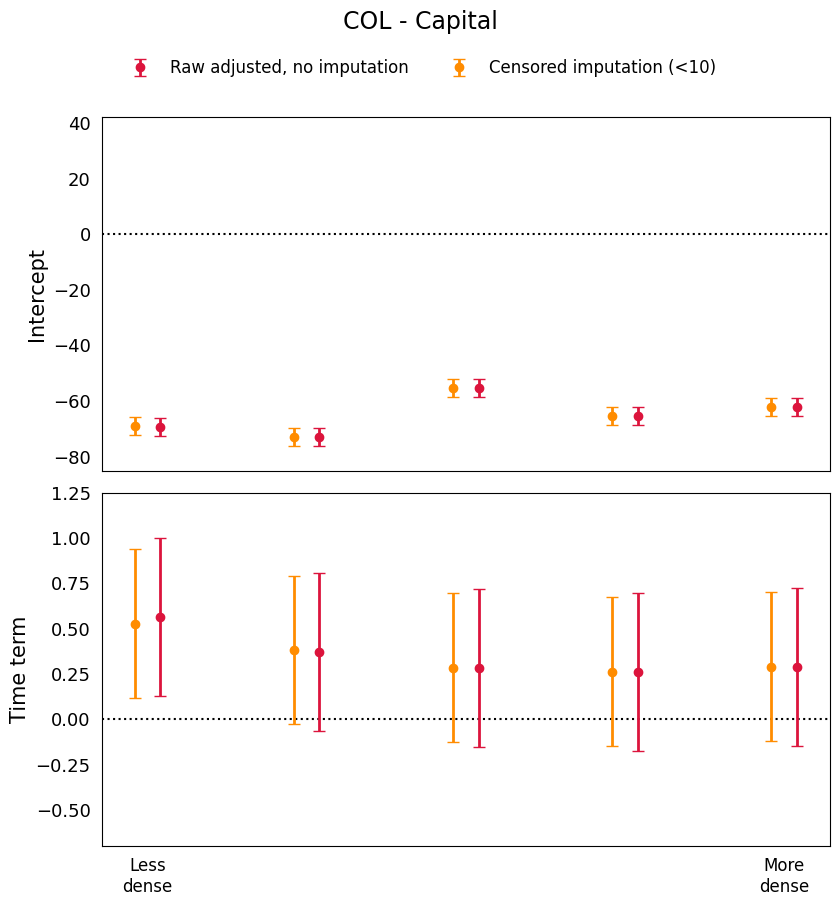

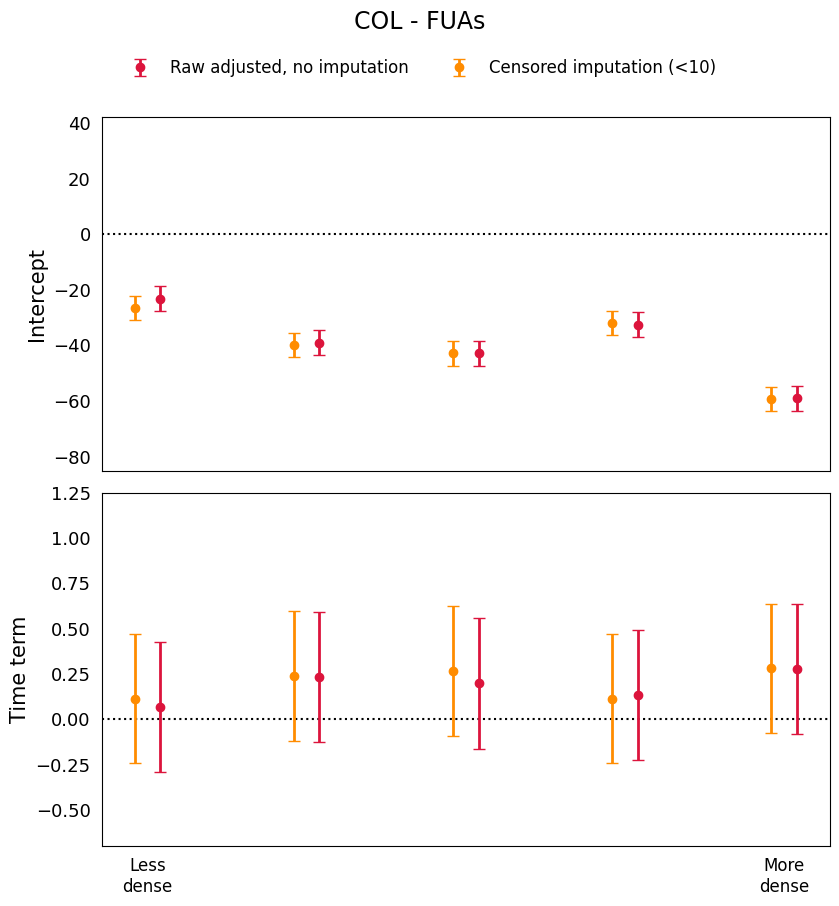

['/your/path/to/working/directory/plots/city-model6-sensitivity-r2/ARG_capital_density_model6_censored10_vs_raw_r2.pdf',
 '/your/path/to/working/directory/plots/city-model6-sensitivity-r2/ARG_fuas_density_model6_censored10_vs_raw_r2.pdf',
 '/your/path/to/working/directory/plots/city-model6-sensitivity-r2/CHL_capital_density_model6_censored10_vs_raw_r2.pdf',
 '/your/path/to/working/directory/plots/city-model6-sensitivity-r2/CHL_fuas_density_model6_censored10_vs_raw_r2.pdf',
 '/your/path/to/working/directory/plots/city-model6-sensitivity-r2/COL_capital_density_model6_censored10_vs_raw_r2.pdf',
 '/your/path/to/working/directory/plots/city-model6-sensitivity-r2/COL_fuas_density_model6_censored10_vs_raw_r2.pdf']

In [23]:
plot_paths = []
for country_short in countries.values():
    for place in places:
        plot_paths.append(
            plot_city_comparison(
                df_long,
                country_short,
                place,
                plot_dir,
                intercept_ylim=intercept_ylim,
                time_ylim=time_ylim,
            )
        )

plot_paths